In [5]:
import pandas as pd

In [6]:
df_normal = pd.read_csv('anomaly-free.csv',sep=';')
df_normal.shape

(9401, 9)

In [7]:
df_normal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9401 entries, 0 to 9400
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             9401 non-null   object 
 1   Accelerometer1RMS    9401 non-null   float64
 2   Accelerometer2RMS    9401 non-null   float64
 3   Current              9401 non-null   float64
 4   Pressure             9401 non-null   float64
 5   Temperature          9401 non-null   float64
 6   Thermocouple         9401 non-null   float64
 7   Voltage              9401 non-null   float64
 8   Volume Flow RateRMS  9401 non-null   float64
dtypes: float64(8), object(1)
memory usage: 661.1+ KB


In [8]:
df_normal.describe()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
count,9401.000000,9401.000000,9401.000000,9401.000000,9401.000000,9401.000000,9401.000000,9401.000000
mean,0.212277,0.268553,2.568057,0.111429,89.506955,28.417508,228.490887,125.140908
std,0.004728,0.004129,6.082034,0.252583,0.673482,0.757808,12.579837,1.671961
min,0.193992,0.248062,0.855284,-1.257000,88.171300,26.765800,1.036640,118.000000
25%,0.210431,0.265524,2.129540,0.054711,88.974200,27.841900,222.625000,124.000000
50%,0.212928,0.267378,2.541080,0.054711,89.380500,28.624800,228.942000,125.672000
75%,0.215262,0.271934,2.728380,0.382638,89.922400,29.068500,234.963000,126.328000
max,0.225967,0.280214,233.203000,1.366420,91.724900,29.522100,252.806000,128.353000


In [9]:
df_normal.head(10)

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
0,2020-02-08 13:30:47,0.206030,0.277924,1.81019,0.382638,90.1740,26.7760,228.208,121.664
1,2020-02-08 13:30:48,0.204366,0.275727,2.66317,-0.273216,90.2836,26.7760,227.245,122.000
2,2020-02-08 13:30:49,0.206103,0.278526,2.63758,0.382638,89.8666,26.7821,237.872,122.000
3,2020-02-08 13:30:51,0.204775,0.276948,2.32851,0.382638,90.2192,26.7773,230.422,121.338
4,2020-02-08 13:30:52,0.206052,0.278141,2.53422,0.382638,90.1449,26.7773,219.454,121.664
5,2020-02-08 13:30:53,0.204336,0.278100,2.56922,0.054711,90.2703,26.7658,221.089,122.000
6,2020-02-08 13:30:54,0.205697,0.278892,1.95859,0.054711,90.2250,26.7750,232.327,122.000
7,2020-02-08 13:30:55,0.204775,0.277663,2.49374,0.054711,90.0302,26.7827,231.269,122.000
8,2020-02-08 13:30:56,0.206435,0.277730,1.87371,0.054711,89.9812,26.7870,228.727,121.338
9,2020-02-08 13:30:57,0.202500,0.278587,2.58620,0.382638,90.1731,26.7865,229.672,121.664


In [10]:
import os
import glob

In [11]:
df_normal['anomaly'] = 0

In [12]:
print("Normal data shape:", df_normal.shape)

Normal data shape: (9401, 10)


In [13]:
valve1_files = []
for i in range(16):  
    df = pd.read_csv(f'valve1/{i}.csv', sep=';')
    df = df.drop(columns=['changepoint'])  # drop the extra column
    valve1_files.append(df)
df_fault = pd.concat(valve1_files, ignore_index=True)

In [14]:
print("Fault data shape:", df_fault.shape)
print(df_fault.head(3))

Fault data shape: (18162, 10)
              datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0  2020-03-09 10:14:33           0.026588           0.040111  1.33020   
1  2020-03-09 10:14:34           0.026170           0.040452  1.35399   
2  2020-03-09 10:14:35           0.026199           0.039419  1.54006   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  anomaly  
0  0.054711      79.3366       26.0199  233.062                 32.0      0.0  
1  0.382638      79.5158       26.0258  236.040                 32.0      0.0  
2  0.710565      79.3756       26.0265  251.380                 32.0      0.0  


In [15]:
df_test = pd.read_csv('valve1/0.csv', sep=';')
print(df_test.columns.tolist())
print(df_test.head(3))

['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
              datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0  2020-03-09 10:14:33           0.026588           0.040111  1.33020   
1  2020-03-09 10:14:34           0.026170           0.040452  1.35399   
2  2020-03-09 10:14:35           0.026199           0.039419  1.54006   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  anomaly  \
0  0.054711      79.3366       26.0199  233.062                 32.0      0.0   
1  0.382638      79.5158       26.0258  236.040                 32.0      0.0   
2  0.710565      79.3756       26.0265  251.380                 32.0      0.0   

   changepoint  
0          0.0  
1          0.0  
2          0.0  


In [16]:
column_names = df_test.columns.tolist()
print(column_names)

['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']


In [17]:
print("\nColumns match:", df_normal.columns.tolist() == df_fault.columns.tolist())


Columns match: True


In [18]:
print("Normal columns:", df_normal.columns.tolist())
print("Fault columns:", df_fault.columns.tolist())

Normal columns: ['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly']
Fault columns: ['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly']


In [19]:
df = pd.concat([df_normal, df_fault], ignore_index=True)

In [20]:
df.shape

(27563, 10)

In [21]:
print(df['anomaly'].value_counts())

anomaly
0.0    21254
1.0     6309
Name: count, dtype: int64


In [22]:
import matplotlib.pyplot as plt

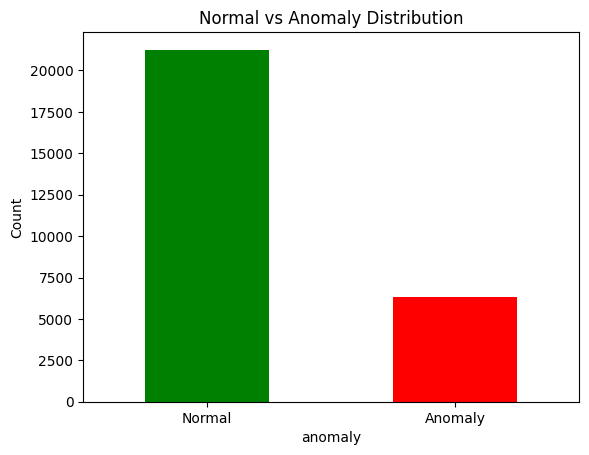

In [23]:
df['anomaly'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Normal vs Anomaly Distribution')
plt.xticks([0, 1], ['Normal', 'Anomaly'], rotation=0)
plt.ylabel('Count')
plt.show()

In [24]:
sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
               'Pressure', 'Temperature', 'Thermocouple',
               'Voltage', 'Volume Flow RateRMS']

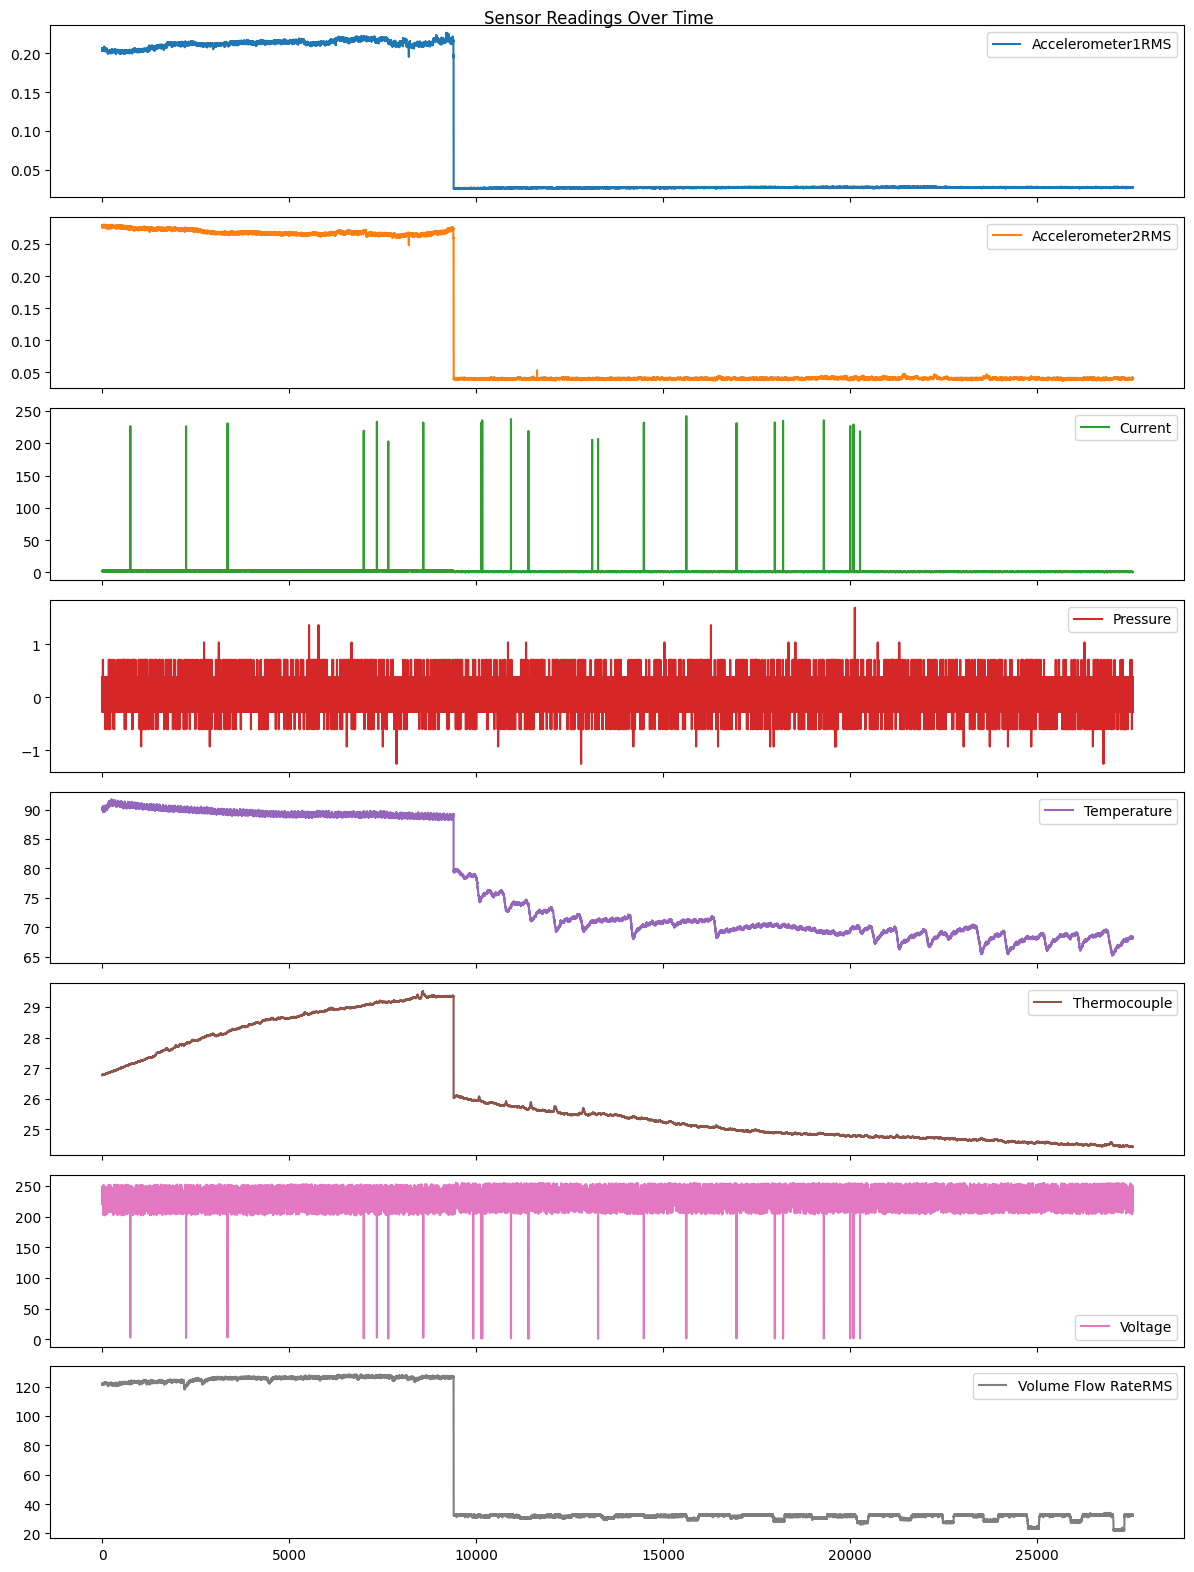

In [25]:
df[sensor_cols].plot(subplots=True, figsize=(
    12, 16), title='Sensor Readings Over Time')
plt.tight_layout()
plt.show()

In [26]:
df.isnull().sum()

datetime               0
Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
dtype: int64

In [27]:
df.dtypes

datetime                object
Accelerometer1RMS      float64
Accelerometer2RMS      float64
Current                float64
Pressure               float64
Temperature            float64
Thermocouple           float64
Voltage                float64
Volume Flow RateRMS    float64
anomaly                float64
dtype: object

In [28]:
df.head()

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
0,2020-02-08 13:30:47,0.206030,0.277924,1.81019,0.382638,90.1740,26.7760,228.208,121.664,0.0
1,2020-02-08 13:30:48,0.204366,0.275727,2.66317,-0.273216,90.2836,26.7760,227.245,122.000,0.0
2,2020-02-08 13:30:49,0.206103,0.278526,2.63758,0.382638,89.8666,26.7821,237.872,122.000,0.0
3,2020-02-08 13:30:51,0.204775,0.276948,2.32851,0.382638,90.2192,26.7773,230.422,121.338,0.0
4,2020-02-08 13:30:52,0.206052,0.278141,2.53422,0.382638,90.1449,26.7773,219.454,121.664,0.0


In [29]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [31]:
df = df.drop(columns=['datetime'])

In [32]:
df.isnull().sum()

Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
dtype: int64

In [33]:
X = df.drop(columns=['anomaly'])
y = df['anomaly']

In [34]:
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (27563, 8)
Target shape: (27563,)


In [35]:
df.shape

(27563, 9)

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [37]:
def create_sliding_windows(X, y, window_size=50):
    X_windows = []
    y_windows = []

    for i in range(len(X) - window_size):
        # Grab 50 rows at a time
        window = X_scaled.iloc[i:i+window_size].values.flatten()
        # Label = if ANY row in window is anomaly → whole window is anomaly
        label = 1 if y.iloc[i:i+window_size].sum() > 0 else 0
        X_windows.append(window)
        y_windows.append(label)

    return np.array(X_windows), np.array(y_windows)

In [38]:
X_win, y_win = create_sliding_windows(X_scaled, y, window_size=50)

In [39]:
print("\nWindowed features shape:", X_win.shape)
print("Windowed target shape:", y_win.shape)


Windowed features shape: (27513, 400)
Windowed target shape: (27513,)


In [40]:
print(pd.Series(y_win).value_counts())

0    20420
1     7093
Name: count, dtype: int64


In [41]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_win, y_win,
    test_size=0.2,
    shuffle=False  # ← critical for time series
)

In [44]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (22010, 400)
Test shape: (5503, 400)


In [45]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles imbalance
    random_state=42
)

In [46]:
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [47]:
print("\n── Random Forest Results ──")
print(classification_report(y_test, rf_preds))


── Random Forest Results ──
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      3258
           1       0.76      0.86      0.81      2245

    accuracy                           0.83      5503
   macro avg       0.83      0.84      0.83      5503
weighted avg       0.84      0.83      0.83      5503



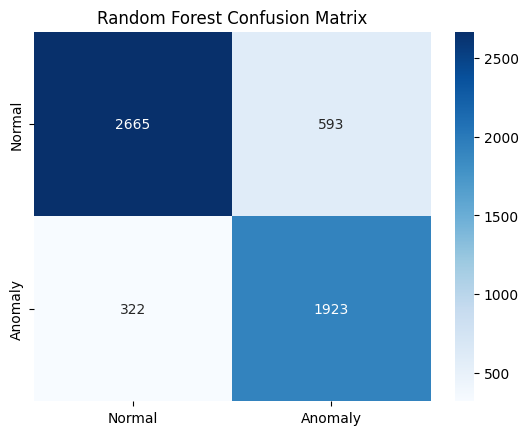

In [48]:
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Random Forest Confusion Matrix')
plt.show()

In [49]:
scale = 20420 / 7093


In [50]:
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [51]:
print("\n── XGBoost Results ──")
print(classification_report(y_test, xgb_preds))


── XGBoost Results ──
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      3258
           1       0.95      0.85      0.89      2245

    accuracy                           0.92      5503
   macro avg       0.92      0.91      0.91      5503
weighted avg       0.92      0.92      0.92      5503



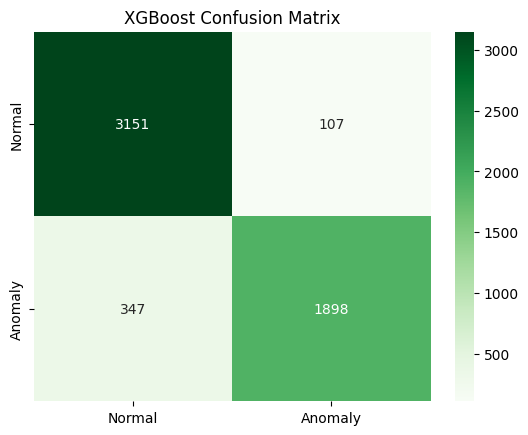

In [52]:
cm2 = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('XGBoost Confusion Matrix')
plt.show()

In [53]:
X_train_normal = X_train[y_train == 0]

In [54]:
iso_model = IsolationForest(
    contamination=0.25,  # roughly our anomaly ratio
    random_state=42
)

In [55]:
iso_model.fit(X_train_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.25
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [56]:
iso_preds = iso_model.predict(X_test)

In [57]:
iso_preds = [0 if p == 1 else 1 for p in iso_preds]

In [58]:
print("── Isolation Forest Results ──")
print(classification_report(y_test, iso_preds))

── Isolation Forest Results ──
              precision    recall  f1-score   support

           0       0.84      0.31      0.45      3258
           1       0.48      0.92      0.63      2245

    accuracy                           0.56      5503
   macro avg       0.66      0.61      0.54      5503
weighted avg       0.69      0.56      0.52      5503



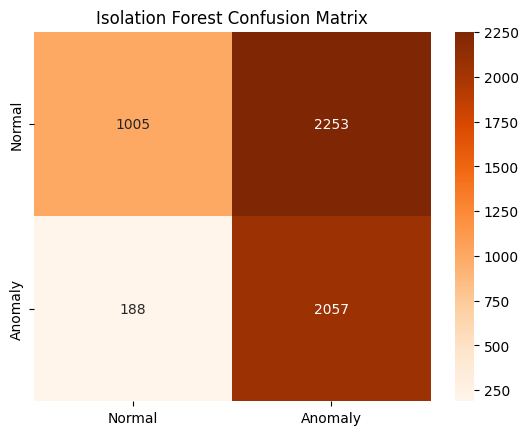

In [59]:
cm3 = confusion_matrix(y_test, iso_preds)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Isolation Forest Confusion Matrix')
plt.show()

In [60]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [62]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# ── STEP 1: PREPARE DATA ──────────────────────────────────────────────
# Autoencoder trains ONLY on normal data
X_train_normal = X_train[y_train == 0]

print("Training on normal data only:", X_train_normal.shape)
#naanza hapa kesho

Training on normal data only: (17162, 400)


In [65]:
# ── STEP 2: BUILD THE AUTOENCODER ─────────────────────────────────────
# Input size = window_size × number of sensors = 50 × 8 = 400
input_dim = X_train.shape[1]  # 400

# ENCODER → compresses data down
# DECODER → reconstructs data back up
# If reconstruction is bad → it's an anomaly

inputs = Input(shape=(input_dim,))

In [66]:
# Encoder
encoded = Dense(256, activation='relu')(inputs)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(64,  activation='relu')(encoded)

# Bottleneck (compressed representation)
bottleneck = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(64,  activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(256, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

In [67]:
# Build model
autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 400)            │       102,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,144 (1.11 MB)

 Trainable params: 292,144 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# ── STEP 3: TRAIN THE AUTOENCODER ─────────────────────────────────────
# Only trains on normal data
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal, X_train_normal,  # input = output (reconstruction)
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.3587 - val_loss: 0.4368
Epoch 2/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3200 - val_loss: 0.4216
Epoch 3/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3052 - val_loss: 0.4116
Epoch 4/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2854 - val_loss: 0.3822
Epoch 5/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2669 - val_loss: 0.3831
Epoch 6/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2481 - val_loss: 0.3390
Epoch 7/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2362 - val_loss: 0.3136
Epoch 8/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2229 - val_loss: 0.2923
Epoch 9/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2138 - val_loss: 0.2746
Epoch 10/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2074 - val_loss: 0.2611
Epoch 11/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2044 - val_loss: 0.2472
Epoch 12/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

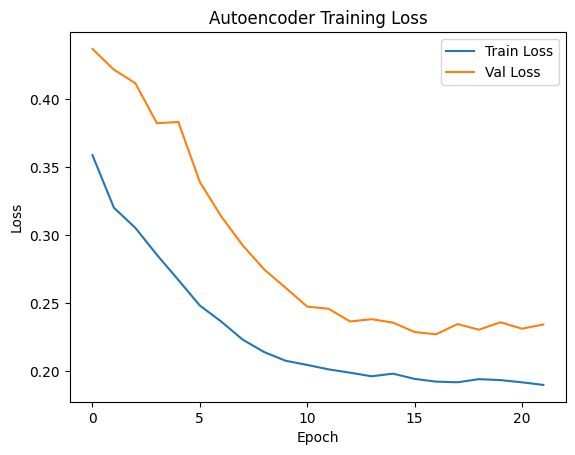

In [70]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [71]:
 #── STEP 4: CALCULATE RECONSTRUCTION ERROR ────────────────────────────
# Reconstruct the test data
X_test_reconstructed = autoencoder.predict(X_test)

# Reconstruction error = how different is input vs output
reconstruction_errors = np.mean(np.power(X_test - X_test_reconstructed, 2), axis=1)


172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


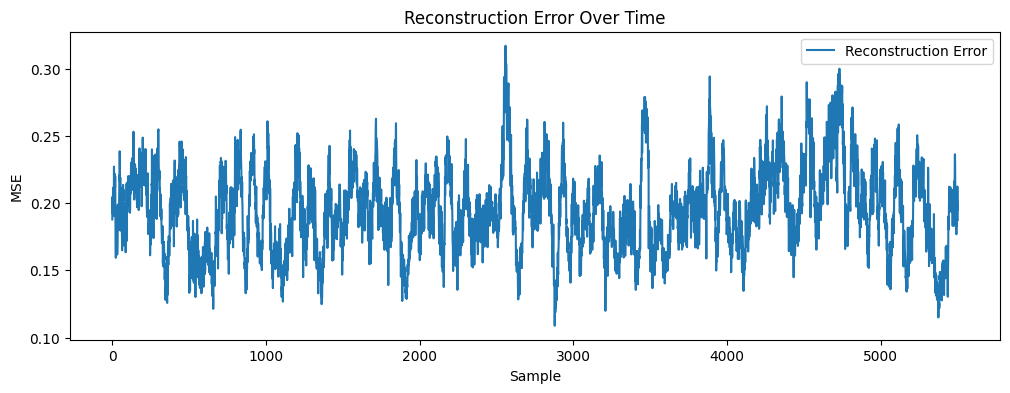

In [72]:
plt.figure(figsize=(12, 4))
plt.plot(reconstruction_errors, label='Reconstruction Error')
plt.title('Reconstruction Error Over Time')
plt.xlabel('Sample')
plt.ylabel('MSE')
plt.legend()
plt.show()

── Autoencoder Best Results ──
              precision    recall  f1-score   support

           0       0.58      0.50      0.54      3258
           1       0.39      0.47      0.43      2245

    accuracy                           0.49      5503
   macro avg       0.49      0.49      0.48      5503
weighted avg       0.50      0.49      0.49      5503



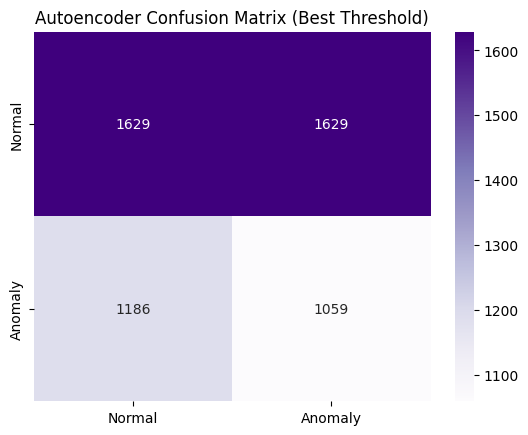

In [78]:
# ── STEP 5: SET THRESHOLD ─────────────────────────────────────────────
# Threshold = 95th percentile of normal reconstruction errors
#normal_errors = reconstruction_errors[y_test == 0]
#threshold = np.percentile(normal_errors, 95)

#print(f"Anomaly Threshold: {threshold:.4f}")

# Anything above threshold = anomaly
#ae_preds = (reconstruction_errors > threshold).astype(int)
# Try different thresholds and see which works best
#for percentile in [50, 60, 70, 75, 80]:
    # threshold = np.percentile(normal_errors, percentile)
    # ae_preds = (reconstruction_errors > threshold).astype(int)
    # from sklearn.metrics import f1_score
    # f1 = f1_score(y_test, ae_preds)
    # print(
        # f"Percentile: {percentile} | Threshold: {threshold:.4f} | F1: {f1:.3f}")
# Percentile: 50 | Threshold: 0.1946 | F1: 0.429 is the best so we rewrite the code to use the threshold emoji
# Use best threshold (percentile 50)
threshold = np.percentile(normal_errors, 50)
ae_preds = (reconstruction_errors > threshold).astype(int)

print("── Autoencoder Best Results ──")
print(classification_report(y_test, ae_preds))

cm4 = confusion_matrix(y_test, ae_preds)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Autoencoder Confusion Matrix (Best Threshold)')
plt.show()

── Autoencoder Results ──
              precision    recall  f1-score   support

           0       0.58      0.50      0.54      3258
           1       0.39      0.47      0.43      2245

    accuracy                           0.49      5503
   macro avg       0.49      0.49      0.48      5503
weighted avg       0.50      0.49      0.49      5503



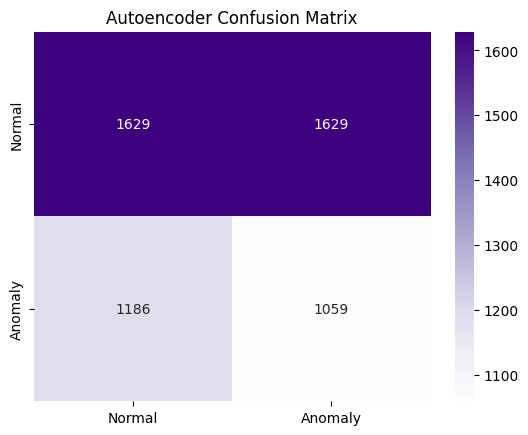

In [79]:
# ── STEP 6: EVALUATE ──────────────────────────────────────────────────
print("── Autoencoder Results ──")
print(classification_report(y_test, ae_preds))

cm4 = confusion_matrix(y_test, ae_preds)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Autoencoder Confusion Matrix')
plt.show()

In [81]:
import joblib
import json

# ── SAVE XGBOOST MODEL ────────────────────────────────────────────────
joblib.dump(xgb_model, 'xgb_model.pkl')

# ── SAVE SCALER ───────────────────────────────────────────────────────
# Important! Dashboard needs same scaling as training
joblib.dump(scaler, 'scaler.pkl')

# ── SAVE THRESHOLD INFO ───────────────────────────────────────────────
model_info = {
    'window_size': 50,
    'n_features': 8,
    'contamination_ratio': 0.25,
    'feature_names': ['Accelerometer1RMS', 'Accelerometer2RMS',
                      'Current', 'Pressure', 'Temperature',
                      'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f)

print("✅ Model saved → xgb_model.pkl")
print("✅ Scaler saved → scaler.pkl")
print("✅ Info saved  → model_info.json")

✅ Model saved → xgb_model.pkl
✅ Scaler saved → scaler.pkl
✅ Info saved  → model_info.json


In [82]:
# Run this in your notebook to get exact versions
import xgboost
import sklearn
import streamlit
import tensorflow
import pandas
import numpy
import matplotlib
import seaborn
import joblib

print(f"xgboost=={xgboost.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"streamlit=={streamlit.__version__}")
print(f"tensorflow=={tensorflow.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"numpy=={numpy.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={seaborn.__version__}")
print(f"joblib=={joblib.__version__}")

xgboost==3.2.0
scikit-learn==1.8.0
streamlit==1.56.0
tensorflow==2.21.0
pandas==2.3.3
numpy==2.4.0
matplotlib==3.10.8
seaborn==0.13.2
joblib==1.5.3
